**Hydra body area analysis from DLC coordinates**

This code analyzes Hydra body area from long behavioral recordings after DeepLabCut tracking.

Input:
A DeepLabCut .csv file containing body-outline coordinates, typically ~16 labeled points around the Hydra body.

What the code does:

Uploads the DLC .csv file in Google Colab.
Removes likelihood columns.
Extracts x/y coordinates for each frame.
Plots the first, middle, and last frames for visual checking.
Calculates body area for each frame using a convex hull around the tracked body points.
Saves and downloads a new .csv file containing frame number and estimated area.

Output:
A file named:

original_filename_ANALYZED.csv

with columns:

Frame, Area

Notes:
The convex hull gives an estimate of the projected body area enclosed by the tracked points.



In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy.spatial import ConvexHull

In [ ]:
# For uploading and downloading files in Google Colab
from google.colab import files

In [ ]:
# Upload the CSV file
uploaded = files.upload()
filename = next(iter(uploaded))

KeyboardInterrupt: 

In [ ]:
# Load the dataset, dropping the first row
df = pd.read_csv(filename, skiprows=[0])

# Drop all likelihood columns
# Assuming 'df' is your DataFrame after reading the CSV

# Identify likelihood columns with a more specific pattern, considering the provided DataFrame structure
likelihood_columns = [col for col in df.columns if col.endswith('.2') or 'likelihood' in col]

# Drop these columns from the DataFrame
df = df.drop(columns=likelihood_columns)

# Since the first row contains what seems to be another header row, drop it as well
df = df.drop(index=0).reset_index(drop=True)

# Convert the remaining 'x' and 'y' columns to numeric values as they are likely read as strings
for col in df.columns[1:]:  # Skipping the first column as it appears to be frame numbers or similar identifiers
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.head())  # Print the first few rows to verify the changes


  bodyparts   bodypart1  bodypart1.1   bodypart2  bodypart2.1   bodypart3  \
0         0  353.110962   366.330139  375.586121   423.021454  414.891907   
1         1  351.309113   364.158020  372.974091   422.844238  413.053711   
2         2  345.732880   370.583801  369.444092   421.129944  411.444061   
3         3  342.962372   367.908508  368.360748   420.915955  411.438232   
4         4  340.641663   366.394043  365.473114   418.542511  409.551117   

   bodypart3.1   bodypart4  bodypart4.1   bodypart5  ...  bodypart12  \
0   488.940063  455.140625   578.260071  609.084717  ...  768.752319   
1   488.234833  453.473755   577.676636  610.573547  ...  765.150208   
2   487.028961  454.115845   577.498840  610.811951  ...  768.373596   
3   486.246582  453.188751   577.686768  595.598145  ...  644.749084   
4   485.601959  452.953156   578.044495  612.150024  ...  694.619324   

   bodypart12.1  bodypart13  bodypart13.1  bodypart14  bodypart14.1  \
0    608.846619  719.187195    57

In [ ]:
# Function to plot points for given frame
def plot_frame(df, frame_idx, title):
    fig, ax = plt.subplots()
    # Extract coordinates for plotting
    x_coords = df.iloc[frame_idx, 1::2].values  # Selecting every second column starting from index 1 for x
    y_coords = df.iloc[frame_idx, 2::2].values  # Selecting every second column starting from index 2 for y

    # Ensure conversion to proper types if needed
    x_coords = np.asarray(x_coords, dtype=float)
    y_coords = np.asarray(y_coords, dtype=float)

    ax.scatter(x_coords, y_coords)
    ax.set_title(title)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid(True)
    plt.show()

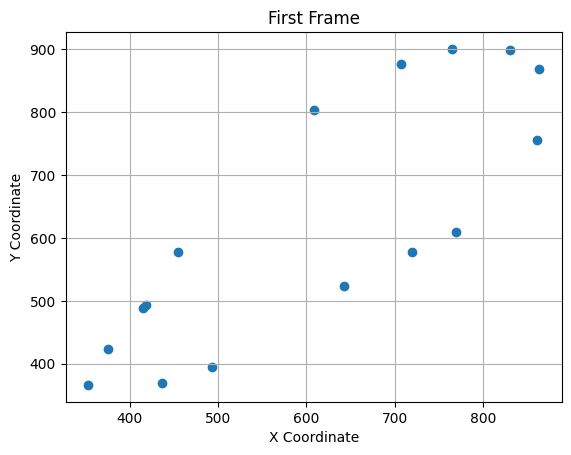

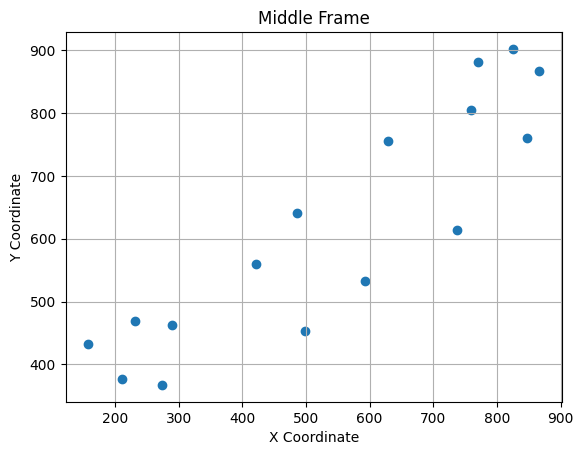

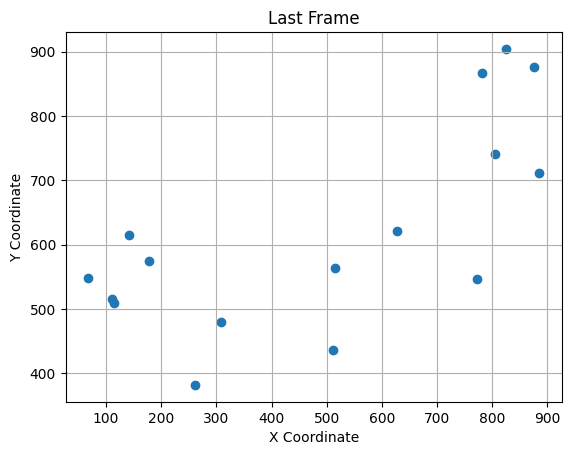

In [ ]:
# Plot the first, middle, and last frame
total_frames = len(df)
plot_frame(df, 0, 'First Frame')
plot_frame(df, total_frames // 2, 'Middle Frame')
plot_frame(df, total_frames - 1, 'Last Frame')


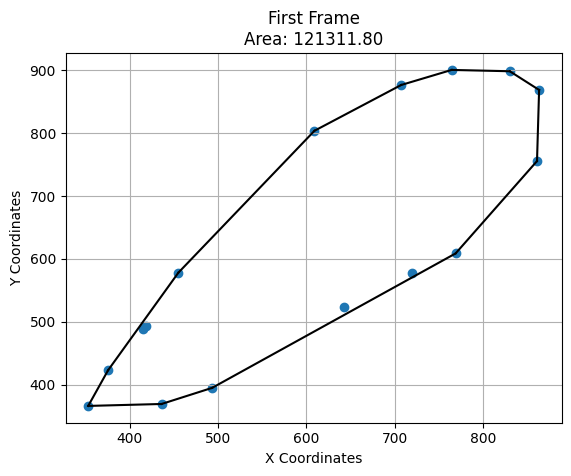

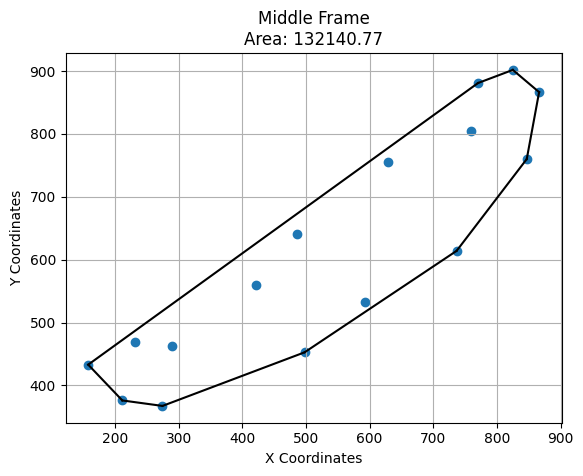

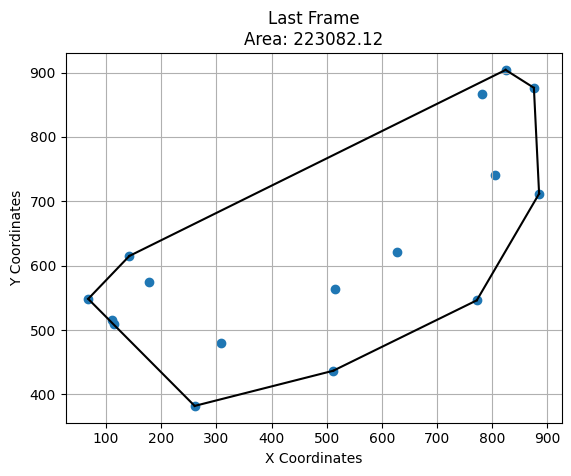

In [ ]:
from scipy.spatial import ConvexHull

# Modified plot_frame function to include Convex Hull
def plot_frame_with_hull(df, frame_idx, title, areas):
    fig, ax = plt.subplots()
    frame = df.iloc[frame_idx]
    x_coords = frame[1::2].values  # Adjusted for x coordinates
    y_coords = frame[2::2].values  # Adjusted for y coordinates

    # Ensure x and y have the same length
    min_length = min(len(x_coords), len(y_coords))
    x_coords = x_coords[:min_length]
    y_coords = y_coords[:min_length]

    # Plot points
    ax.scatter(x_coords, y_coords)

    # Create Convex Hull
    points = np.column_stack((x_coords, y_coords))
    hull = ConvexHull(points)

    # Plot Convex Hull
    for simplex in hull.simplices:
        ax.plot(points[simplex, 0], points[simplex, 1], 'k-')  # 'k-' for black line

    # Display the area of the Convex Hull in the title or as text within the plot
    ax.set_title(f"{title}\nArea: {areas[frame_idx]:.2f}")

    plt.xlabel('X Coordinates')
    plt.ylabel('Y Coordinates')
    plt.grid(True)
    plt.show()

# Assuming 'areas' is the list of areas computed for each frame using the Convex Hull
# You need to call this modified function for the specific frames you're interested in
total_frames = len(df)
plot_frame_with_hull(df, 0, 'First Frame', areas)
plot_frame_with_hull(df, total_frames // 2, 'Middle Frame', areas)
plot_frame_with_hull(df, total_frames - 1, 'Last Frame', areas)

In [ ]:
# Compute the area using the Convex Hull method
def compute_area(points):
    hull = ConvexHull(points)
    return hull.volume

This code uses the ConvexHull method from scipy.spatial to calculate the area. The area of the convex hull that encloses the set of points is a good approximation for the area occupied by the animal in each frame.
The function compute_area calculates the area of the convex hull for a given set of points. Convex hull is a minimal convex set enclosing all points, and its "volume" attribute gives the area in 2D.

In [ ]:
# Initialize a list to store areas
areas = []

In [ ]:
# Compute area for each frame, adjusting for the correct column indexing
areas = []  # Ensure this list is initialized before the loop if not already done

for i in range(total_frames):
    frame = df.iloc[i]
    # Adjust indexing to correctly select x and y coordinates
    x_coords = frame[1::2].values  # Start from the second column for x coordinates
    y_coords = frame[2::2].values  # Start from the third column for y coordinates
    points = np.column_stack((x_coords, y_coords))
    area = compute_area(points)
    areas.append(area)

In [ ]:
# Create a new DataFrame for areas
frame_numbers = np.arange(total_frames)
areas_df = pd.DataFrame({'Frame': frame_numbers, 'Area': areas})

In [ ]:
# Save the new DataFrame to a new CSV file
new_filename = filename + '_ANALYZED.csv'
areas_df.to_csv(new_filename, index=False)

In [ ]:
# Download the new CSV file
files.download(new_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>